# 03 - Exploratory Data Analysis

Goal: answer concrete business questions about the cleaned transaction data.
Every chart here answers a specific question — not decoration.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

clean_df = pd.read_csv(
    "../data/processed/retail_clean.csv",
    parse_dates=["InvoiceDate"],
    low_memory=False
)
clean_df.shape

(1007913, 9)

## Q1: How big is this business, at a glance?

In [2]:
print("Unique customers:", clean_df["Customer ID"].nunique())
print("Unique products:", clean_df["StockCode"].nunique())
print("Unique countries:", clean_df["Country"].nunique())
print("Unique invoices:", clean_df["Invoice"].nunique())
print("Total revenue:", round(clean_df["TotalAmount"].sum(), 2))
print("Average transaction line value:", round(clean_df["TotalAmount"].mean(), 2))

Unique customers: 5878
Unique products: 4917
Unique countries: 43
Unique invoices: 40077
Total revenue: 20476260.45
Average transaction line value: 20.32


## Q2: Which countries drive revenue?

In [3]:
country_revenue = (
    clean_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
country_revenue

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: TotalAmount, dtype: float64

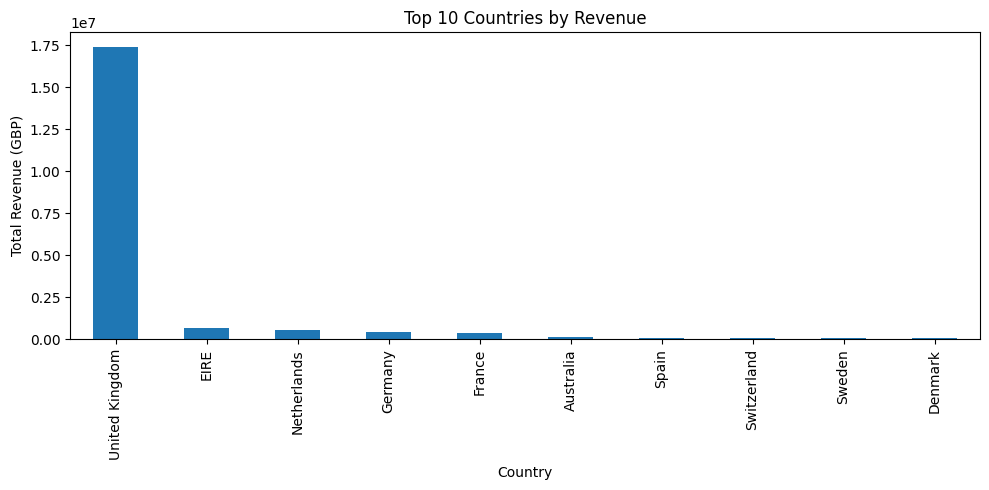

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
country_revenue.plot(kind="bar", ax=ax)
ax.set_title("Top 10 Countries by Revenue")
ax.set_ylabel("Total Revenue (GBP)")
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_country.png")
plt.show()

**UK alone accounts for ~85% of total revenue.** This matters for later steps:
Country as a feature for segmentation or prediction is only meaningfully granular
for the UK — every other country has too few customers to treat as its own
category with any statistical weight. We'll likely bucket non-UK countries
together rather than one-hot encoding all 43.

## Q3: What are the top-selling products by revenue?

In [5]:
top_products = (
    clean_df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: TotalAmount, dtype: float64

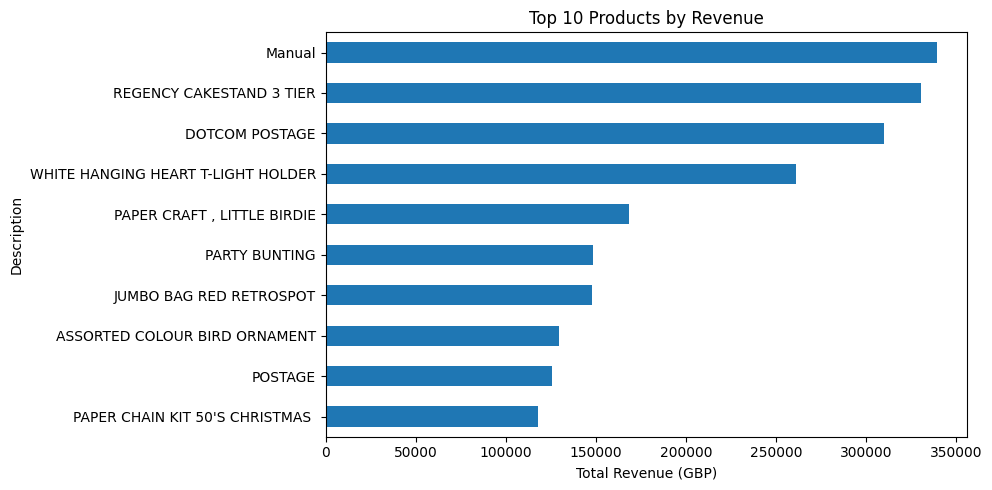

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
top_products.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Total Revenue (GBP)")
plt.tight_layout()
plt.savefig("../reports/figures/top_products.png")
plt.show()

## Q4: How does revenue trend over time?

In [7]:
monthly_revenue = (
    clean_df.set_index("InvoiceDate")["TotalAmount"]
    .resample("ME")
    .sum()
)
monthly_revenue

InvoiceDate
2009-12-31     822483.950
2010-01-31     651155.112
2010-02-28     551504.726
2010-03-31     830915.261
2010-04-30     678875.252
2010-05-31     657705.500
2010-06-30     749537.310
2010-07-31     648810.270
2010-08-31     695251.910
2010-09-30     921696.991
2010-10-31    1161902.220
2010-11-30    1464293.142
2010-12-31     821452.730
2011-01-31     689811.610
2011-02-28     522545.560
2011-03-31     716215.260
2011-04-30     536968.491
2011-05-31     769296.610
2011-06-30     760547.010
2011-07-31     718076.121
2011-08-31     757841.380
2011-09-30    1056435.192
2011-10-31    1151263.730
2011-11-30    1503866.780
2011-12-31     637808.330
Freq: ME, Name: TotalAmount, dtype: float64

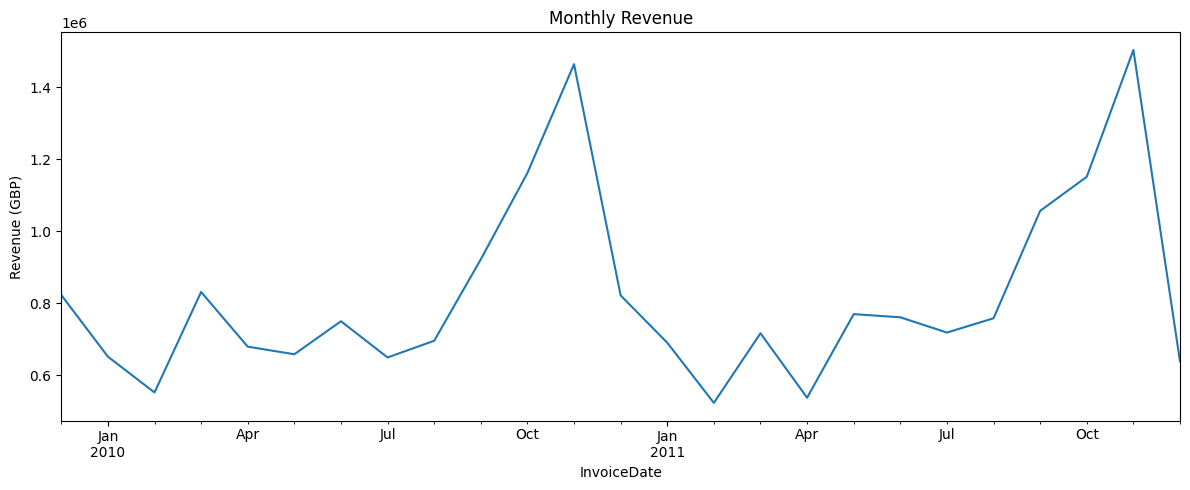

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
monthly_revenue.plot(ax=ax)
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue (GBP)")
plt.tight_layout()
plt.savefig("../reports/figures/monthly_revenue.png")
plt.show()

Note: the first and last months are likely partial (data starts Dec 1 2009,
ends Dec 9 2011) — don't read a drop in the final bar as a real trend, it's
a truncated month.

## Q5: What does transaction value distribution look like?

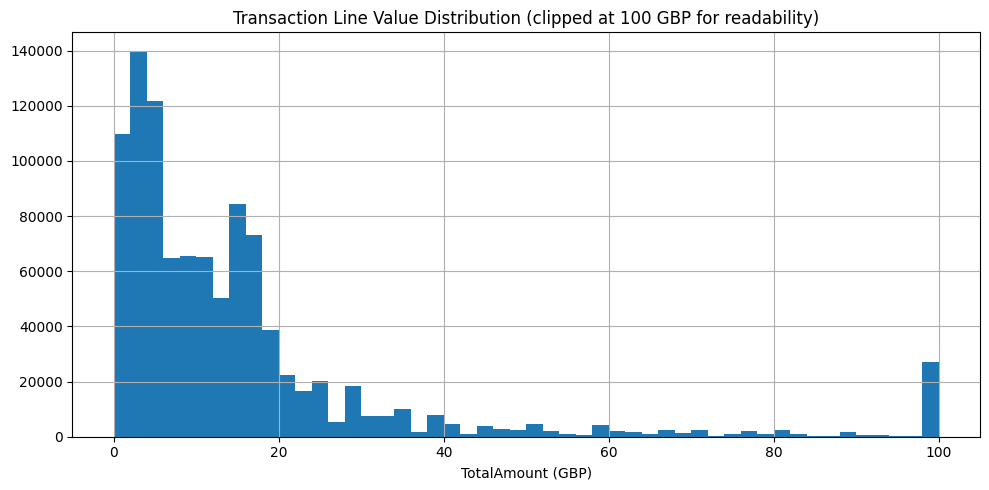

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
clean_df["TotalAmount"].clip(upper=100).hist(bins=50, ax=ax)
ax.set_title("Transaction Line Value Distribution (clipped at 100 GBP for readability)")
ax.set_xlabel("TotalAmount (GBP)")
plt.tight_layout()
plt.savefig("../reports/figures/transaction_value_distribution.png")
plt.show()

Clipped at 100 GBP because the raw distribution is extremely right-skewed —
a small number of bulk/wholesale orders are worth thousands of pounds and would
compress the histogram into a single bar otherwise.

## Q6: How many invoices does the average customer place?

In [10]:
customer_df = clean_df.dropna(subset=["Customer ID"])
invoices_per_customer = customer_df.groupby("Customer ID")["Invoice"].nunique()
invoices_per_customer.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

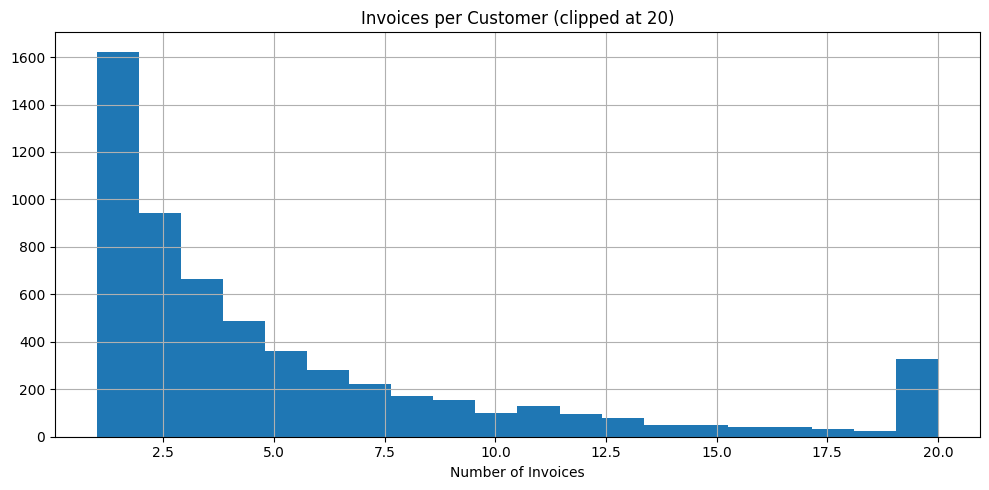

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
invoices_per_customer.clip(upper=20).hist(bins=20, ax=ax)
ax.set_title("Invoices per Customer (clipped at 20)")
ax.set_xlabel("Number of Invoices")
plt.tight_layout()
plt.savefig("../reports/figures/invoices_per_customer.png")
plt.show()

Median is far below the mean here — most customers order only a handful of
times, while a small number of frequent/wholesale buyers pull the average up.
This is the same skew we'll need to handle carefully in RFM feature engineering
(next notebook) — raw Monetary/Frequency will need transformation before KMeans,
or clusters will just separate "whales" from "everyone else" without useful
granularity.